# Лінійні моделі

## 1. Лінійна регресія з однією змінною 
### Набір даних: California Housing (fetch_california_housing) 
- Завдання:
    - Використати тільки ознаку MedInc (середній дохід у районі) для передбачення MedHouseVal (середня ціна будинку).
    - Побудувати модель LinearRegression.
    - Обчислити MAE, MSE, R² на тестовому наборі.
    - Візуалізувати графік: MedInc vs MedHouseVal із передбаченою лінією регресії.

Перші 5 рядків наших даних:
   median_income  median_house_value
0         8.3252            452600.0
1         8.3014            358500.0
2         7.2574            352100.0
3         5.6431            341300.0
4         3.8462            342200.0
---------------------------------------------------------------------------

Розмір тренувального набору: 16512 рядків
Розмір тестового набору: 4128 рядків
---------------------------------------------------------------------------

Модель успішно навчена!
---------------------------------------------------------------------------

Середня абсолютна помилка (MAE): $62,990.87
Середня квадратична помилка (MSE): 7,091,157,771.77
Коефіцієнт детермінації (R²): 0.46
---------------------------------------------------------------------------


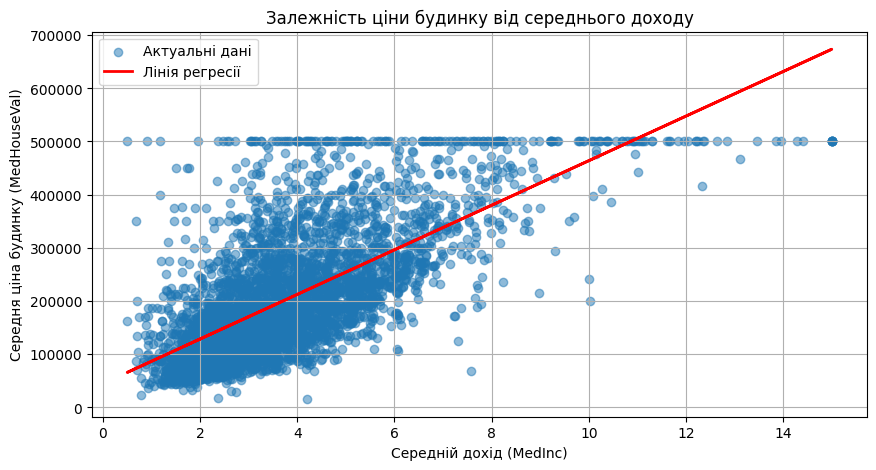

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Завантажуємо дані з CSV файлу
df = pd.read_csv('California Housing Prices.csv')

# Вибираємо стовпці
X = df[['median_income']]
y = df['median_house_value']
print("Перші 5 рядків наших даних:")
print(df[['median_income', 'median_house_value']].head())
print("-" * 75)


# Ділимо дані на тренувальні та тестові (80% на тренування, 20% на тест)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nРозмір тренувального набору: {X_train.shape[0]} рядків")
print(f"Розмір тестового набору: {X_test.shape[0]} рядків")
print("-" * 75)


model = LinearRegression()  # Створюємо модель лінійної регресії
model.fit(X_train, y_train) # Навчаємо модель на тренувальних даних
print("\nМодель успішно навчена!")
print("-" * 75)


# Робимо передбачення на тестових даних
y_pred = model.predict(X_test)  
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nСередня абсолютна помилка (MAE): ${mae:,.2f}")
print(f"Середня квадратична помилка (MSE): {mse:,.2f}")
print(f"Коефіцієнт детермінації (R²): {r2:.2f}")
print("-" * 75)


# Створюємо графік
plt.figure(figsize=(10, 5))  
plt.scatter(X_test, y_test, alpha=0.5, label='Актуальні дані')   # Малюємо реальні дані (тестовий набір) у вигляді точок
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Лінія регресії')  # Малюємо лінію регресії (наші передбачення)
plt.title('Залежність ціни будинку від середнього доходу')
plt.xlabel('Середній дохід (MedInc)')
plt.ylabel('Середня ціна будинку (MedHouseVal)')
plt.legend()
plt.grid(True)
plt.show()

## 2. Множинна регресія 
### Набір даних: California Housing 
- Завдання:
    - Використати ознаки: MedInc, AveRooms, AveOccup, HouseAge.
    - Масштабувати ознаки за допомогою StandardScaler.
    - Побудувати LinearRegression для передбачення MedHouseVal.
    - Оцінити MAE, MSE, R² на тестовому наборі.
    - Пояснити, як масштабування впливає на результати.

Наші ознаки (перші 5 рядків):
       median_income  AveRooms  AveOccup  housing_median_age
14196         3.2596  5.017657  3.691814                33.0
8267          3.8125  4.473545  1.738095                49.0
17445         4.1563  5.645833  2.723214                 4.0
14265         1.9425  4.002817  3.994366                36.0
2271          3.5542  6.268421  2.300000                43.0
---------------------------------------------------------------------------

Середня абсолютна помилка (MAE): $60,254.80
Середня квадратична помилка (MSE): 6,574,517,278.82
Коефіцієнт детермінації (R²): 0.50
---------------------------------------------------------------------------


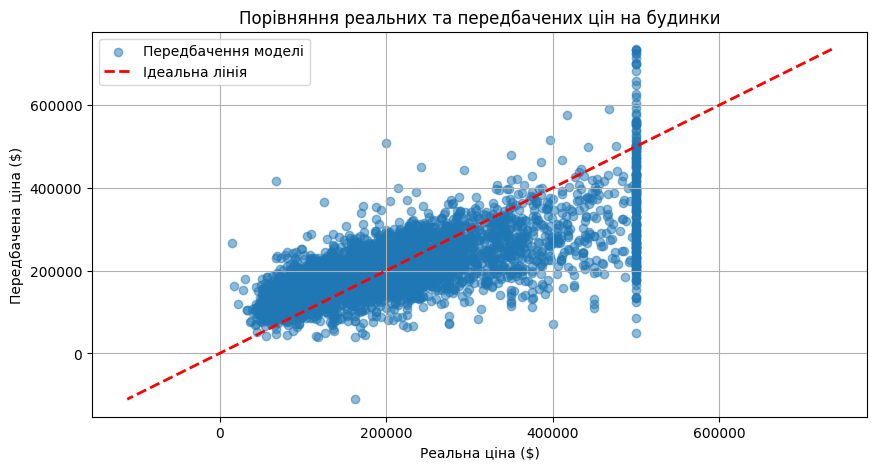

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Завантажуємо дані
df = pd.read_csv('California Housing Prices.csv')
# Створюємо нові ознаки
df['AveRooms'] = df['total_rooms'] / df['households']
df['AveOccup'] = df['population'] / df['households']


# Вибираємо  стовпці для X та y
features = ['median_income', 'AveRooms', 'AveOccup', 'housing_median_age']
target = 'median_house_value'
X = df[features]
y = df[target]
# Ділимо дані на тренувальні та тестові
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Наші ознаки (перші 5 рядків):")
print(X_train.head())
print("-" * 75)


scaler = StandardScaler()  # Створюємо об'єкт для масштабування
X_train_scaled = scaler.fit_transform(X_train)  # Налаштовуємо скалер на тренувальних даних і трансформуємо їх
X_test_scaled = scaler.transform(X_test)  # Трансформуємо тестові дані


model = LinearRegression()  # Створюємо та навчаємо модель на масштабованих даних
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)  # Робимо передбачення на масштабованих тестових даних

# Оцінюємо модель
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nСередня абсолютна помилка (MAE): ${mae:,.2f}")
print(f"Середня квадратична помилка (MSE): {mse:,.2f}")
print(f"Коефіцієнт детермінації (R²): {r2:.2f}")
print("-" * 75)


# Створюємо графік для візуалізації
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5, label='Передбачення моделі')  # Діаграму розсіювання: реальні значення проти передбачених
p1 = max(max(y_pred), max(y_test.values))  # Координати початку лінії
p2 = min(min(y_pred), min(y_test.values))  # Координати кінця лінії
plt.plot([p1, p2], [p1, p2], 'r--', linewidth=2, label='Ідеальна лінія')  # Лінія (де реальна ціна = передбаченій)

plt.title('Порівняння реальних та передбачених цін на будинки')
plt.xlabel('Реальна ціна ($)')
plt.ylabel('Передбачена ціна ($)')
plt.legend()
plt.grid(True)
plt.show()

## 3. Поліноміальна регресія 
### Набір даних: California Housing 
- Завдання:
    - Використати ознаки MedInc та HouseAge.
    - Створити поліноміальні ознаки до 3-го степеня (PolynomialFeatures).
    - Побудувати LinearRegression.
    - Порівняти метрики з лінійною регресією.
    - Візуалізувати криву передбачення.

Початкова кількість ознак: 2
Кількість ознак після трансформації: 9
---------------------------------------------------------------------------

--- Результати Поліноміальної Регресії ---
Середня абсолютна помилка (MAE): $58,737.49
Коефіцієнт детермінації (R²): 0.52
---------------------------------------------------------------------------


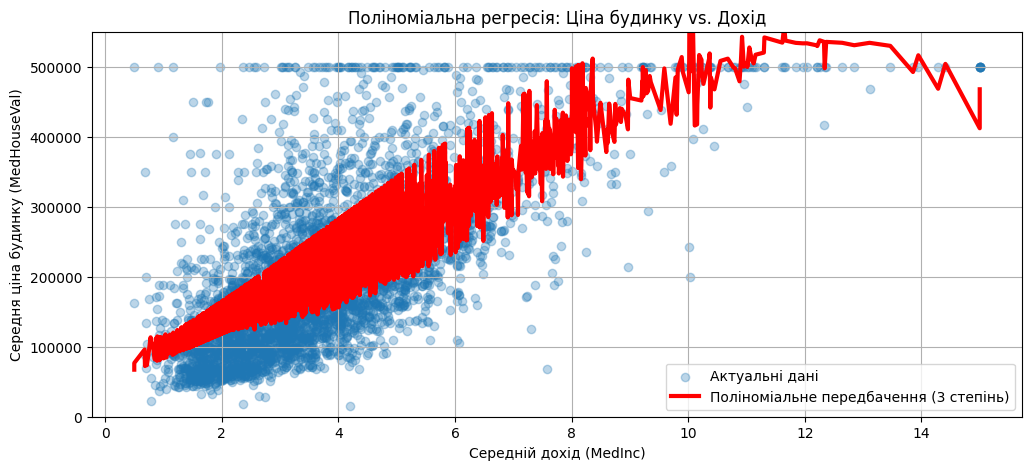

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Завантажуємо дані
df = pd.read_csv('California Housing Prices.csv')

# Вибираємо ознаки та цільову змінну
features = ['median_income', 'housing_median_age']
target = 'median_house_value'
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
poly_features = PolynomialFeatures(degree=3, include_bias=False)  # Створюємо поліноміальні ознаки 3-го степеня
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

print(f"Початкова кількість ознак: {X_train.shape[1]}")
print(f"Кількість ознак після трансформації: {X_train_poly.shape[1]}")
print("-" * 75)


poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)  # Навчаємо модель на нових даних
y_pred_poly = poly_model.predict(X_test_poly)  # Робимо передбачення

# Оцінюємо модель
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("\n--- Результати Поліноміальної Регресії ---")
print(f"Середня абсолютна помилка (MAE): ${mae_poly:,.2f}")
print(f"Коефіцієнт детермінації (R²): {r2_poly:.2f}")
print("-" * 75)


sorted_test_data = sorted(zip(X_test['median_income'], y_pred_poly))  # Для візуалізації сортуємо дані по осі X
X_test_sorted, y_pred_poly_sorted = zip(*sorted_test_data)

# Візуалізуємо
plt.figure(figsize=(12, 5))
plt.scatter(X_test['median_income'], y_test, alpha=0.3, label='Актуальні дані')
plt.plot(X_test_sorted, y_pred_poly_sorted, color='red', linewidth=3, label='Поліноміальне передбачення (3 степінь)')

plt.title('Поліноміальна регресія: Ціна будинку vs. Дохід')
plt.xlabel('Середній дохід (MedInc)')
plt.ylabel('Середня ціна будинку (MedHouseVal)')
plt.legend()
plt.ylim(0, 550000)
plt.grid(True)
plt.show()

## 4. Регуляризація Lasso та Ridge 
### Набір даних: California Housing 
- Завдання:
    - Використати всі числові ознаки.
    - Побудувати моделі Lasso та Ridge.
    - Підбрати оптимальний параметр α за допомогою GridSearchCV.
    - Порівняти результати з лінійною регресією без регуляризації.
    - Висновок: яка регуляризація дала найменшу помилку?

Найкращий параметр alpha для Ridge: 10
Найкращий параметр alpha для Lasso: 50
---------------------------------------------------------------------------
    Модель      MAE             MSE     R²
0  Лінійна  $51,810  $5,059,928,371  0.614
1    Ridge  $51,792  $5,055,159,513  0.614
2    Lasso  $51,800  $5,055,901,173  0.614


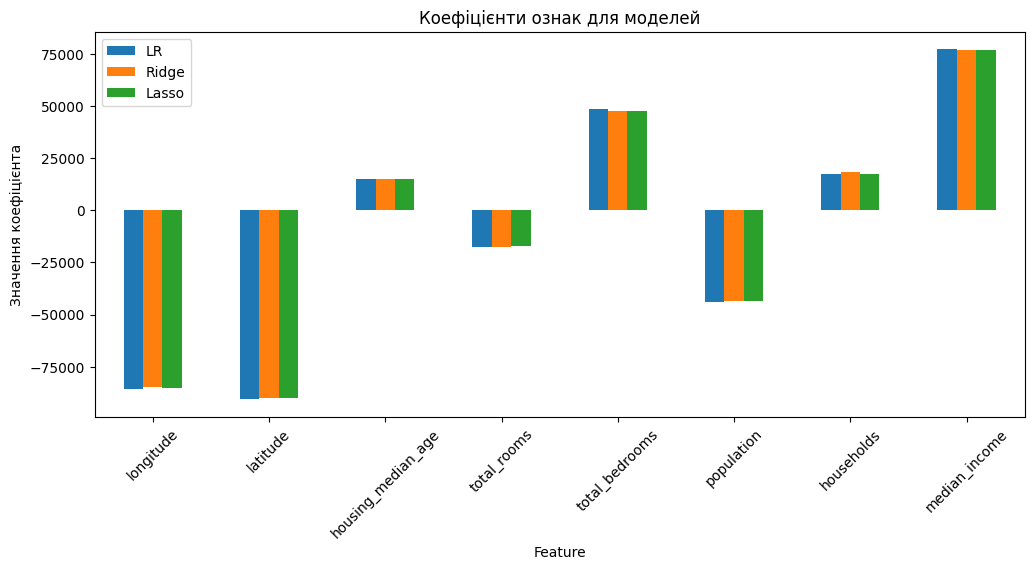

---------------------------------------------------------------------------


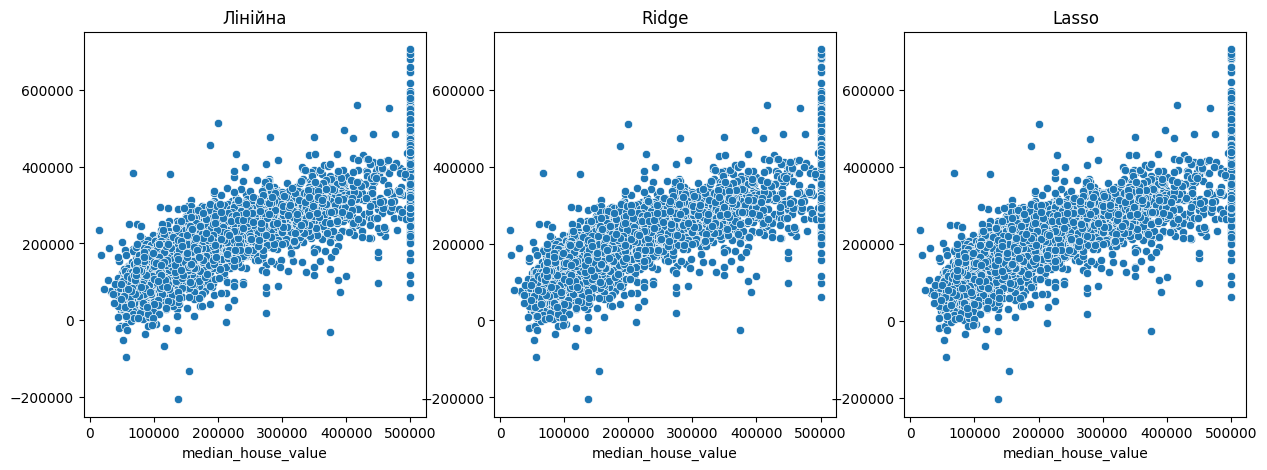

---------------------------------------------------------------------------


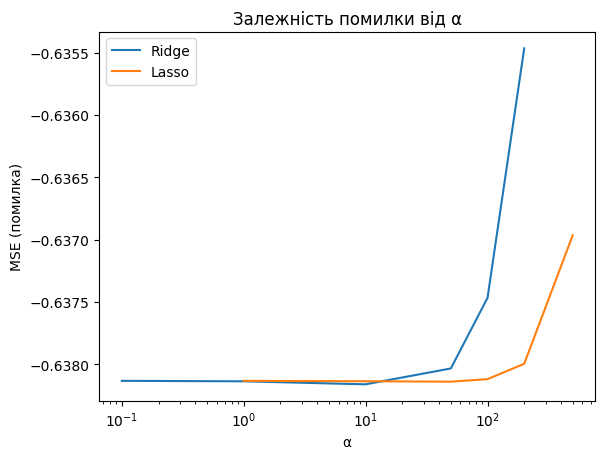

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, r2_score

# Завантажуємо дані
df = pd.read_csv('California Housing Prices.csv')

# Вибираємо тільки числові колонки, крім ціни
X = df.select_dtypes(include=np.number).drop('median_house_value', axis=1)
y = df['median_house_value']

# Заповнюємо пропущені значення
X['total_bedrooms'] = X['total_bedrooms'].fillna(X['total_bedrooms'].median())

# Ділимо дані та масштабуємо їх
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- Налаштовуємо Ridge ---
ridge = Ridge()
params_ridge = {'alpha': [0.1, 1, 10, 50, 100, 200]}  # Створюємо сітку параметрів 'alpha' для перебору
ridge_cv = GridSearchCV(ridge, params_ridge, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

# --- Налаштовуємо Lasso ---
lasso = Lasso(max_iter=10000)
params_lasso = {'alpha': [1, 10, 50, 100, 200, 500]}
lasso_cv = GridSearchCV(lasso, params_lasso, cv=5)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Найкращий параметр alpha для Ridge: {ridge_cv.best_params_['alpha']}")
print(f"Найкращий параметр alpha для Lasso: {lasso_cv.best_params_['alpha']}")
print("-" * 75)


# Будемо порівнювати прогнози
# Моделі
lr = LinearRegression().fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
mae_lr, mse_lr, r2_lr = mean_absolute_error(y_test, y_pred_lr), mean_squared_error(y_test, y_pred_lr), r2_score(y_test, y_pred_lr)

y_pred_ridge = ridge_cv.predict(X_test_scaled)
mae_ridge, mse_ridge, r2_ridge = mean_absolute_error(y_test, y_pred_ridge), mean_squared_error(y_test, y_pred_ridge), r2_score(y_test, y_pred_ridge)

y_pred_lasso = lasso_cv.predict(X_test_scaled)
mae_lasso, mse_lasso, r2_lasso = mean_absolute_error(y_test, y_pred_lasso), mean_squared_error(y_test, y_pred_lasso), r2_score(y_test, y_pred_lasso)

# Таблиця 
results = pd.DataFrame({
    'Модель': ['Лінійна', 'Ridge', 'Lasso'],
    'MAE': [f"${mae_lr:,.0f}", f"${mae_ridge:,.0f}", f"${mae_lasso:,.0f}"],
    'MSE': [f"${mse_lr:,.0f}", f"${mse_ridge:,.0f}", f"${mse_lasso:,.0f}"],
    'R²': [f"{r2_lr:.3f}", f"{r2_ridge:.3f}", f"{r2_lasso:.3f}"]
})
print(results)

# Візуалізація 1: Коефіцієнти моделей (бар-графік)
features = X.columns
coefs = pd.DataFrame({
    'Feature': features,
    'LR': lr.coef_,
    'Ridge': ridge_cv.best_estimator_.coef_,
    'Lasso': lasso_cv.best_estimator_.coef_
})
coefs.plot(x='Feature', kind='bar', figsize=(12, 5))
plt.title('Коефіцієнти ознак для моделей')
plt.ylabel('Значення коефіцієнта')
plt.xticks(rotation=45)
plt.show()
print("-" * 75)

# Візуалізація 2: Актуальне vs Передбачене (scatter для кожної)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.scatterplot(x=y_test, y=y_pred_lr, ax=axes[0]).set_title('Лінійна')
sns.scatterplot(x=y_test, y=y_pred_ridge, ax=axes[1]).set_title('Ridge')
sns.scatterplot(x=y_test, y=y_pred_lasso, ax=axes[2]).set_title('Lasso')
plt.show()
print("-" * 75)

# Візуалізація 3: Помилка vs α (для Ridge та Lasso)
alphas_ridge = params_ridge['alpha']
errors_ridge = [-ridge_cv.cv_results_['mean_test_score'][i] for i in range(len(alphas_ridge))]  # Інвертуємо, бо score = -MSE
plt.plot(alphas_ridge, errors_ridge, label='Ridge')
alphas_lasso = params_lasso['alpha']
errors_lasso = [-lasso_cv.cv_results_['mean_test_score'][i] for i in range(len(alphas_lasso))]
plt.plot(alphas_lasso, errors_lasso, label='Lasso')
plt.xscale('log')
plt.xlabel('α')
plt.ylabel('MSE (помилка)')
plt.title('Залежність помилки від α')
plt.legend()
plt.show()

# Дерева рішень

### 5. Набір даних: California Housing 
- Завдання:
    - Використати ознаки MedInc, AveRooms, HouseAge.
    - Побудувати DecisionTreeRegressor із критерієм squared_error.
    - Візуалізувати дерево (plot_tree).
    - Визначити, яка ознака найбільше впливає на передбачення.

Розмір наших даних:
Ознаки (X): (20640, 3)
Ціль (y): (20640,)
---------------------------------------------------------------------------

Перші 5 рядків наших ознак:
   median_income  AveRooms  housing_median_age
0         8.3252  6.984127                41.0
1         8.3014  6.238137                21.0
2         7.2574  8.288136                52.0
3         5.6431  5.817352                52.0
4         3.8462  6.281853                52.0
---------------------------------------------------------------------------

Модель дерева рішень успішно навчена!
---------------------------------------------------------------------------


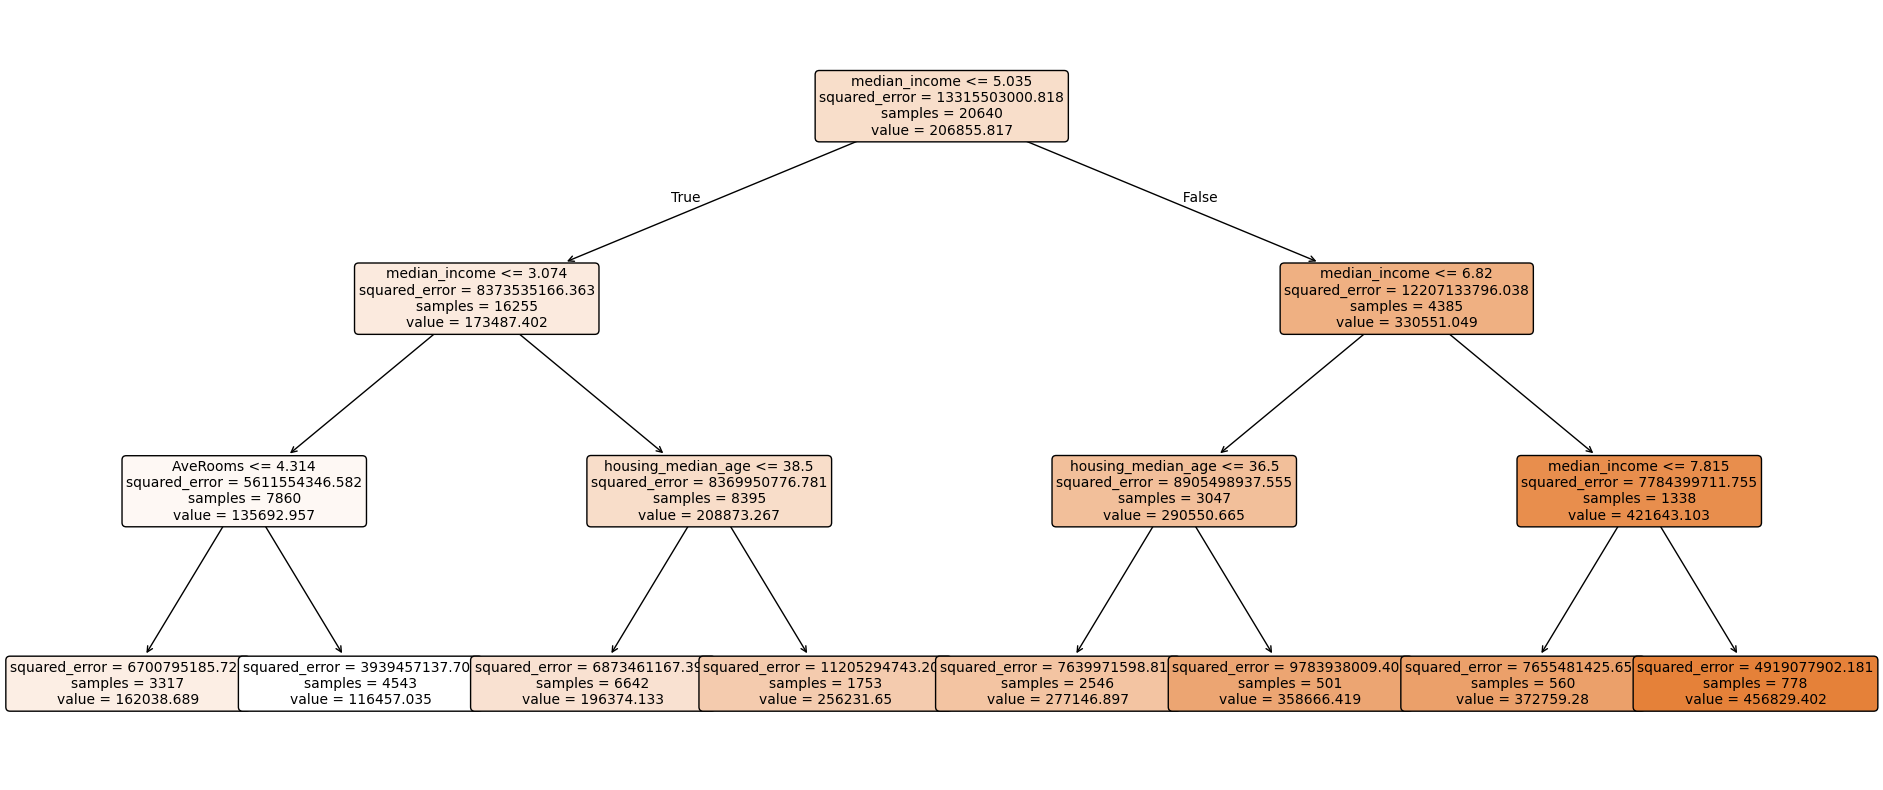

In [18]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Завантажуємо дані
df = pd.read_csv('California Housing Prices.csv')

# Створюємо нову ознаку 'AveRooms'
df['AveRooms'] = df['total_rooms'] / df['households']

features = ['median_income', 'AveRooms', 'housing_median_age']
target = 'median_house_value'

X = df[features]  # ознаки
y = df[target]    # ціль

print("Розмір наших даних:")
print("Ознаки (X):", X.shape)
print("Ціль (y):", y.shape)
print("-" * 75)


print("\nПерші 5 рядків наших ознак:")
print(X.head())
print("-" * 75)


# Створюємо модель DecisionTreeRegressor
tree_regressor = DecisionTreeRegressor(criterion='squared_error', max_depth=3, random_state=42)

# "Навчаємо" модель на наших даних
tree_regressor.fit(X, y)
print("\nМодель дерева рішень успішно навчена!")
print("-" * 75)


# Створbмо зображення для візуалізації
plt.figure(figsize=(24, 10))

# Малюємо дерево
plot_tree(tree_regressor,
          feature_names=features,
          filled=True,      
          rounded=True,     
          fontsize=10)      
plt.show()

## 6. Випадковий ліс 
#### Набір даних: California Housing 
- Завдання:
    - Використати всі числові ознаки.
    - Побудувати RandomForestRegressor з 100 деревами.
    - Порівняти MAE та R² з простим деревом рішень.
    - Побудувати графік важливості ознак (feature_importances_).

--- Підготовка даних ---
Кількість ознак для навчання: 10
Розмір тренувального набору: 16512 об'єктів
Розмір тестового набору: 4128 об'єктів
---------------------------------------------------------------------------

--- Результати Random Forest Regressor ---
Середня абсолютна помилка (MAE) Random Forest: $32,822.08
Коефіцієнт детермінації (R²) Random Forest: 0.803
---------------------------------------------------------------------------

--- Результати Decision Tree Regressor ---
Середня абсолютна помилка (MAE) Decision Tree: $45,290.20
Коефіцієціїнт детермінації (R²) Decision Tree: 0.624
---------------------------------------------------------------------------

--- Порівняння моделей ---
Random Forest MAE: $32,822.08 | Decision Tree MAE: $45,290.20
Random Forest R²: 0.803 | Decision Tree R²: 0.624
---------------------------------------------------------------------------


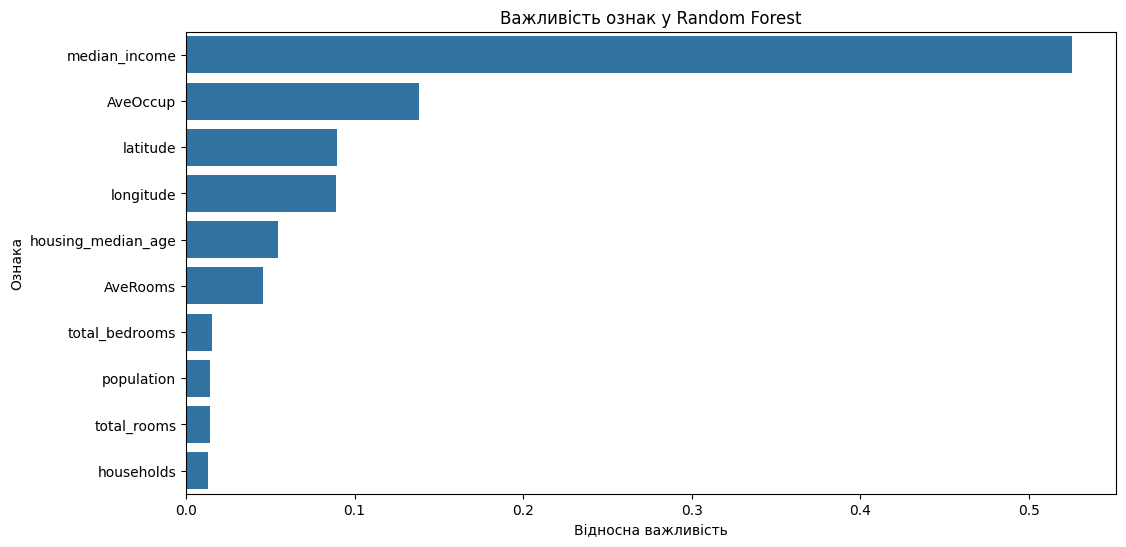


Найважливіші ознаки (з Random Forest):
median_income         0.525521
AveOccup              0.138365
latitude              0.089790
longitude             0.089116
housing_median_age    0.054640
dtype: float64


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor # Це наш "ліс"
from sklearn.tree import DecisionTreeRegressor    # Це "одне дерево"
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Завантажуємо наші дані про будинки
df = pd.read_csv('California Housing Prices.csv')

# Заповнюємо пропущені значення у total_bedrooms (як ми робили раніше)
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# Створюємо нові ознаки, які можуть бути корисними
df['AveRooms'] = df['total_rooms'] / df['households']
df['AveOccup'] = df['population'] / df['households']

# Вибираємо всі числові ознаки, крім цільової змінної
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
if 'median_house_value' in numerical_features:
    numerical_features.remove('median_house_value')

X = df[numerical_features] # Це наші "підказки" (ознаки)
y = df['median_house_value'] # Це те, що ми будемо передбачити (ціна будинку)

# Ділимо дані на тренувальні та тестові
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Підготовка даних ---")
print(f"Кількість ознак для навчання: {X.shape[1]}")
print(f"Розмір тренувального набору: {X_train.shape[0]} об'єктів")
print(f"Розмір тестового набору: {X_test.shape[0]} об'єктів")
print("-" * 75)


# --- Будуємо RandomForestRegressor ---
# Ми створюємо "ліс" зі 100 дерев. Кожне дерево працює трохи по-своєму.
forest_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
forest_model.fit(X_train, y_train) # Навчаємо наш ліс на тренувальних даних

y_pred_forest = forest_model.predict(X_test) # Робимо передбачення на тестових даних

# Оцінюємо наш ліс
mae_forest = mean_absolute_error(y_test, y_pred_forest)
r2_forest = r2_score(y_test, y_pred_forest)

print("\n--- Результати Random Forest Regressor ---")
print(f"Середня абсолютна помилка (MAE) Random Forest: ${mae_forest:,.2f}")
print(f"Коефіцієнт детермінації (R²) Random Forest: {r2_forest:.3f}")
print("-" * 75)


# --- Порівнюємо з простим деревом рішень ---
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train) # Навчаємо одне дерево

y_pred_tree = tree_model.predict(X_test) # Робимо передбачення одним деревом

# Оцінюємо одне дерево
mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("\n--- Результати Decision Tree Regressor ---")
print(f"Середня абсолютна помилка (MAE) Decision Tree: ${mae_tree:,.2f}")
print(f"Коефіцієціїнт детермінації (R²) Decision Tree: {r2_tree:.3f}")
print("-" * 75)


print("\n--- Порівняння моделей ---")
print(f"Random Forest MAE: ${mae_forest:,.2f} | Decision Tree MAE: ${mae_tree:,.2f}")
print(f"Random Forest R²: {r2_forest:.3f} | Decision Tree R²: {r2_tree:.3f}")
print("-" * 75)


# --- Будуємо графік важливості ознак ---
feature_importances = pd.Series(forest_model.feature_importances_, index=numerical_features)
feature_importances_sorted = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importances_sorted.values, y=feature_importances_sorted.index)
plt.title('Важливість ознак у Random Forest')
plt.xlabel('Відносна важливість')
plt.ylabel('Ознака')
plt.show()

print("\nНайважливіші ознаки (з Random Forest):")
print(feature_importances_sorted.head(5))

## 7. Градієнтний бустинг (XGBoost) 
### Набір даних: California Housing 
- Завдання:
    - Використати всі числові ознаки.
    - Побудувати модель XGBRegressor.
    - Підібрати кількість дерев (n_estimators) та швидкість навчання (learning_rate).
    - Порівняти результати з Random Forest.
    - Обговорити, чому бустинг може давати кращу точність.

--- Підготовка даних ---
Кількість ознак для навчання: 10
Розмір тренувального набору: 16512 об'єктів
Розмір тестового набору: 4128 об'єктів
---------------------------------------------------------------------------

--- Пошук найкращих параметрів для XGBoost (GridSearchCV) ---
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Найкращі параметри для XGBoost: {'learning_rate': 0.1, 'n_estimators': 300}
Середня абсолютна помилка (MAE) XGBoost: $29,493.48
Коефіцієнт детермінації (R²) XGBoost: 0.846
---------------------------------------------------------------------------

--- Результати Random Forest Regressor (для порівняння) ---
Середня абсолютна помилка (MAE) Random Forest: $32,822.08
Коефіцієнт детермінації (R²) Random Forest: 0.803
---------------------------------------------------------------------------

--- Остаточне порівняння MAE та R² ---
XGBoost MAE: $29,493.48 | Random Forest MAE: $32,822.08
XGBoost R²: 0.846 | Random Forest R²: 0.803
--------------------------

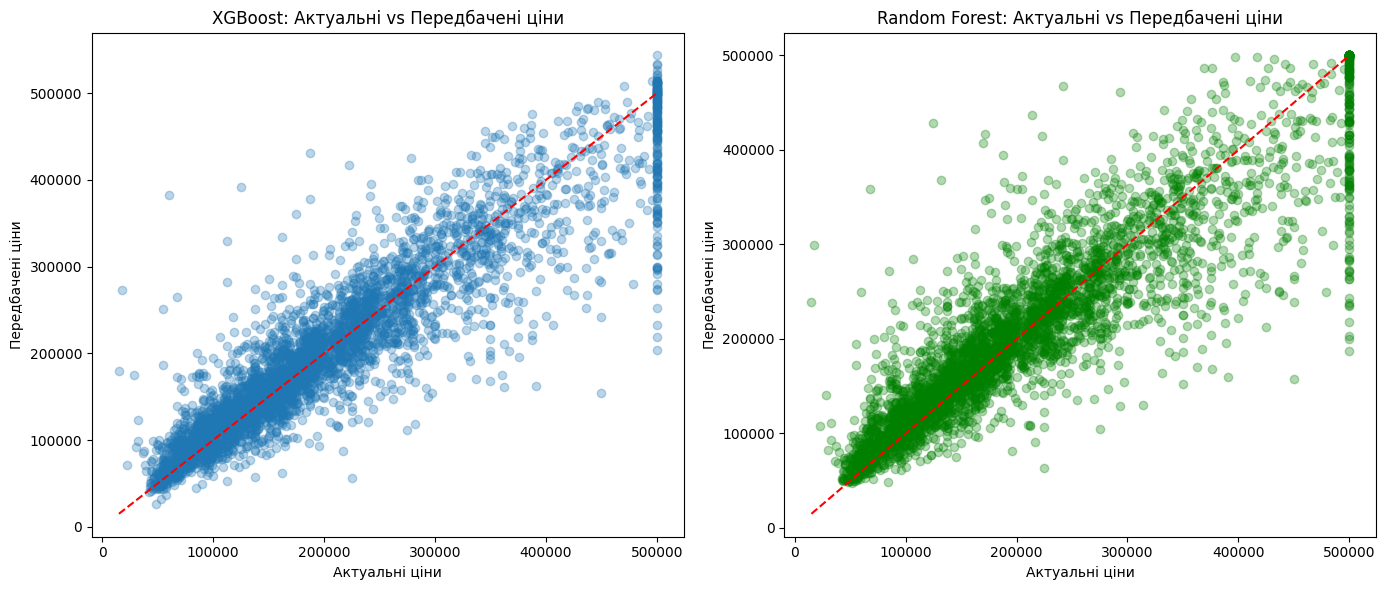


--- Важливість ознак для XGBoost ---


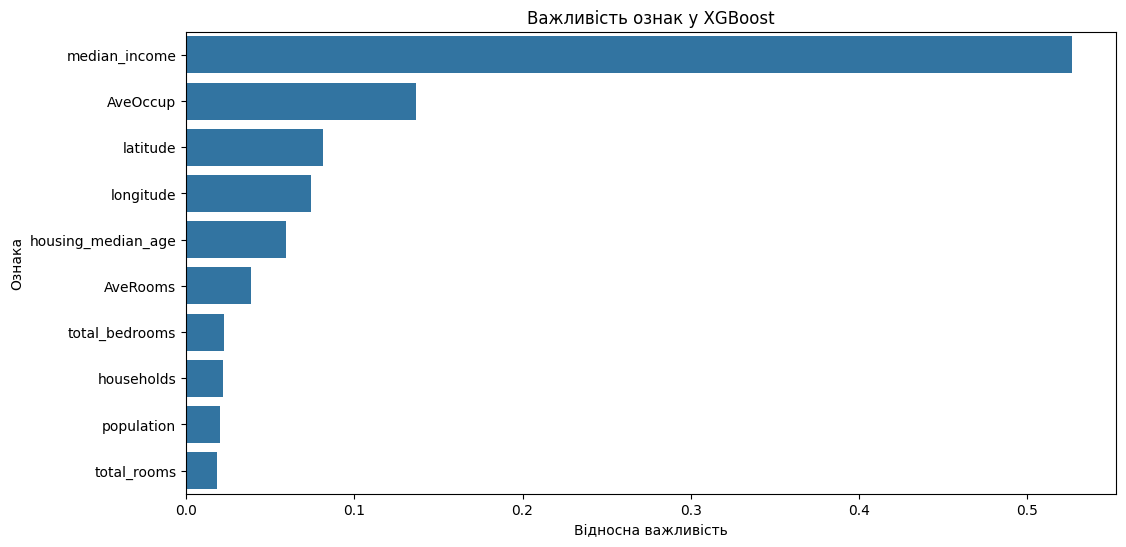

median_income         0.526416
AveOccup              0.136955
latitude              0.081692
longitude             0.074029
housing_median_age    0.059492
dtype: float32


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb # Це наш градієнтний бустинг
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

# Завантажуємо наші дані про будинки
df = pd.read_csv('California Housing Prices.csv')

# Заповнюємо пропущені значення у total_bedrooms
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# Створюємо нові ознаки, які можуть бути корисними
df['AveRooms'] = df['total_rooms'] / df['households']
df['AveOccup'] = df['population'] / df['households']

# Вибираємо всі числові ознаки, крім цільової змінної
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
if 'median_house_value' in numerical_features:
    numerical_features.remove('median_house_value')

X = df[numerical_features]
y = df['median_house_value']

# Ділимо дані на тренувальні та тестові
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Підготовка даних ---")
print(f"Кількість ознак для навчання: {X.shape[1]}")
print(f"Розмір тренувального набору: {X_train.shape[0]} об'єктів")
print(f"Розмір тестового набору: {X_test.shape[0]} об'єктів")
print("-" * 75)


# --- Будуємо модель XGBRegressor ---
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='mae', random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [100, 200, 300], # Кількість дерев
    'learning_rate': [0.05, 0.1, 0.2] # Швидкість "навчання на помилках"
}

print("\n--- Пошук найкращих параметрів для XGBoost (GridSearchCV) ---")
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           cv=3, scoring='neg_mean_absolute_error', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_xgb_model = grid_search.best_estimator_ # Наша найкраща модель XGBoost
y_pred_xgb = best_xgb_model.predict(X_test) # Робимо передбачення

# Оцінюємо модель XGBoost
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\nНайкращі параметри для XGBoost: {grid_search.best_params_}")
print(f"Середня абсолютна помилка (MAE) XGBoost: ${mae_xgb:,.2f}")
print(f"Коефіцієнт детермінації (R²) XGBoost: {r2_xgb:.3f}")
print("-" * 75)


# --- Порівнюємо результати з Random Forest ---
forest_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
forest_model.fit(X_train, y_train)
y_pred_forest = forest_model.predict(X_test)

# Оцінюємо модель Random Forest Regressor
mae_forest = mean_absolute_error(y_test, y_pred_forest)
r2_forest = r2_score(y_test, y_pred_forest)

print("\n--- Результати Random Forest Regressor (для порівняння) ---")
print(f"Середня абсолютна помилка (MAE) Random Forest: ${mae_forest:,.2f}")
print(f"Коефіцієнт детермінації (R²) Random Forest: {r2_forest:.3f}")
print("-" * 75)


print("\n--- Остаточне порівняння MAE та R² ---")
print(f"XGBoost MAE: ${mae_xgb:,.2f} | Random Forest MAE: ${mae_forest:,.2f}")
print(f"XGBoost R²: {r2_xgb:.3f} | Random Forest R²: {r2_forest:.3f}")
print("-" * 75)


# Візуалізація передбачень обох моделей
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_xgb, alpha=0.3)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.title('XGBoost: Актуальні vs Передбачені ціни')
plt.xlabel('Актуальні ціни')
plt.ylabel('Передбачені ціни')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_forest, alpha=0.3, color='green')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.title('Random Forest: Актуальні vs Передбачені ціни')
plt.xlabel('Актуальні ціни')
plt.ylabel('Передбачені ціни')

plt.tight_layout()
plt.show()


# Візуалізація важливості ознак для XGBoost
print("\n--- Важливість ознак для XGBoost ---")
xgb_feature_importances = pd.Series(best_xgb_model.feature_importances_, index=X.columns)
xgb_feature_importances_sorted = xgb_feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=xgb_feature_importances_sorted.values, y=xgb_feature_importances_sorted.index)
plt.title('Важливість ознак у XGBoost')
plt.xlabel('Відносна важливість')
plt.ylabel('Ознака')
plt.show()
print(xgb_feature_importances_sorted.head(5))

#### Обговорення: Чому бустинг може давати кращу точність?
- Навчання на помилках:
    - XGBoost вчиться поступово.
    - Кожна нова модель у лісі фокусується на тих прикладах, де попередні моделі зробили найбільші помилки.
    - Це дозволяє моделі стати дуже точною в тих місцях, де прогнозувати було важко.
    - Random Forest, натомість, будує дерева паралельно, і вони не вчаться одне в одного.
- Зменшення упередженості:
    - Бустинг, вдосконалюючи модель на кожному кроці,
    - ефективно зменшує "упередженість" (bias) моделі – це означає, що вона робить менше систематичних помилок.
- Стійкість до перенавчання (з правильними параметрами):
    - Хоча бустинг може бути схильним до перенавчання (коли модель стає занадто хорошою для тренувальних даних і погано працює на нових),
    - такі параметри, як learning_rate (швидкість навчання) та n_estimators (кількість дерев), дозволяють нам контролювати цей процес.
    - Ми можемо зробити навчання повільнішим і поступовішим, щоб модель краще узагальнювала.

# Класифікація

## 8. Логістична регресія 
### Набір даних: Titanic (train.csv) 
- Завдання:
    - Використати ознаки Pclass, Sex, Age, Fare, Embarked.
    - Заповнити відсутні значення Age середнім (SimpleImputer).
    - Перетворити категоріальні ознаки (Sex, Embarked) методом One-hot encoding.
    - Побудувати LogisticRegression для передбачення Survived.
    - Обчислити Confusion matrix, Precision, Recall, F1 score.

--- Результати оцінки моделі ---
Точність (Precision): 0.76
Повнота (Recall): 0.74
F1-оцінка (F1 Score): 0.75
---------------------------------------------------------------------------

Звіт по класифікації:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

---------------------------------------------------------------------------


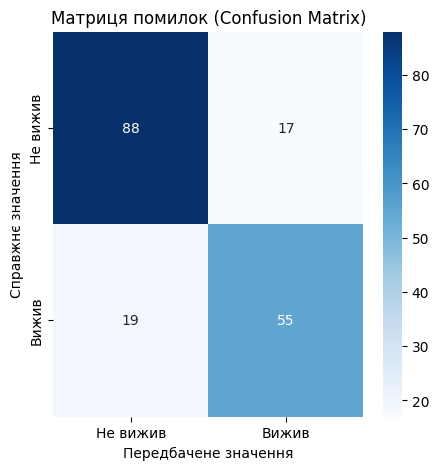

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report
from sklearn.impute import SimpleImputer

# --- Завантажуємо дані ---
try:
    df = pd.read_csv('train.csv')
except FileNotFoundError:
    print("Файл train.csv не знайдено. Будь ласка, переконайтеся, що він знаходиться в тій самій папці.")
    exit()


# Обираємо тільки ті стовпці (ознаки), які нам потрібні для аналізу.
# 'Survived' - це наша ціль: 1 означає, що пасажир вижив, 0 - що ні.
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Survived']
df = df[features]


# Заповнюємо пропуски у стовпці 'Age' (Вік) середнім значенням.
imputer = SimpleImputer(strategy='mean')
df['Age'] = imputer.fit_transform(df[['Age']])


# Заповнимо У стовпці 'Embarked' (Порт посадки) найпопулярнішим портом (модою).
most_frequent_port = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_frequent_port)


# Створюються нові стовпці: наприклад, 'Sex_male' та 'Sex_female'. 
# Якщо пасажир чоловік у 'Sex_male' буде 1, а в 'Sex_female' - 0.
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)


# --- Розділяємо дані на навчальні та тестові ---
X = df.drop('Survived', axis=1) # Всі ознаки, крім цільової
y = df['Survived']               # Цільова ознака (хто вижив)


# Ділимо дані: 80% для навчання, 20% для тесту.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# --- Будуємо та вчимо моделі логістичної регресії ---
model = LogisticRegression(max_iter=1000) # Створюємо модель
model.fit(X_train, y_train)               # Навчаємо модель на тренувальних даних


y_pred = model.predict(X_test) # Робимо передбачення


# Обчислюємо метрики, щоб зрозуміти, наскільки добре модель впоралася.
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print("--- Результати оцінки моделі ---")
print(f"Точність (Precision): {precision:.2f}")
print(f"Повнота (Recall): {recall:.2f}")
print(f"F1-оцінка (F1 Score): {f1:.2f}")
print("-" * 75)

print("\nЗвіт по класифікації:")
print(classification_report(y_test, y_pred))
print("-" * 75)

# --- Візуалізуємо результати ---
plt.figure(figsize=(5, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не вижив', 'Вижив'],
            yticklabels=['Не вижив', 'Вижив'])
plt.xlabel('Передбачене значення')
plt.ylabel('Справжнє значення')
plt.title('Матриця помилок (Confusion Matrix)')
plt.show()

## 9. Обробка категоріальних ознак та пропусків 
### Набір даних: Titanic 
- Завдання:
    - Використати ознаки Sex, Embarked, Pclass, Age, SibSp.
    - Заповнити пропуски Age середнім.
    - Використати factorize для Sex та One-hot encoding для Embarked.
    - Побудувати LogisticRegression та оцінити точність на тестовому наборі.

--- Результати моделі ---
Ознаки, що використовувались: ['Sex', 'Pclass', 'Age', 'SibSp', 'Embarked_Q', 'Embarked_S']
Точність моделі на тестовому наборі: 0.8045 (або 80.45%)
---------------------------------------------------------------------------


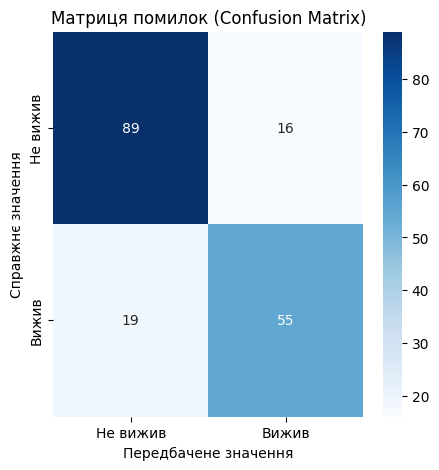

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# --- Завантажуємо дані ---
try:
    df = pd.read_csv('train.csv')
except FileNotFoundError:
    print("Файл train.csv не знайдено. Будь ласка, переконайтеся, що він знаходиться в тій самій папці.")
    exit()


# Обираємо тільки ті стовпці, які вказані в завданні.
features = ['Sex', 'Embarked', 'Pclass', 'Age', 'SibSp', 'Survived']
df = df[features]


# --- Заповненюємо пропуски ---
# У деяких пасажирів не вказано вік. Ми заповнимо ці пропуски середнім віком усіх пасажирів.
mean_age = df['Age'].mean()
df['Age'] = df['Age'].fillna(mean_age)

# Також заповнимо пропуски в 'Embarked', найпопулярнішим портом.
df['Embarked'] = df['Embarked'].fillna(most_frequent_port)


# Використовуємо factorize для ознаки 'Sex'.
# Присвоюємо ('male', 'female') число (0, 1).
df['Sex'] = pd.factorize(df['Sex'])[0]

# Використовуємо One-hot encoding для ознаки 'Embarked'.
# Створює нові окремі стовпці для кожного порту (S, C, Q).
# Наприклад, якщо пасажир сів у порту 'S', у новому стовпці 'Embarked_S' буде 1, а в інших - 0.
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)


# Розділимо наші дані на
X = df.drop('Survived', axis=1)  # "ознаки" (X), за якими ми робимо прогноз
y = df['Survived']  # "ціль" (y), яку ми хочемо передбачити

# Ділимо дані на дві частини: для навчання (80%) і для тестування (20%).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LogisticRegression(max_iter=1000)  # Створюємо модель логістичної регресії.
model.fit(X_train, y_train)  # "Навчаємо" нашу модель на тренувальних даних.
y_pred = model.predict(X_test)  # Робимо передбачення на тестових даних, які модель ще не бачила.
accuracy = accuracy_score(y_test, y_pred)  # Обчислюємо точність правильних відповідей моделі.


print(f"--- Результати моделі ---")
print(f"Ознаки, що використовувались: {list(X.columns)}")
print(f"Точність моделі на тестовому наборі: {accuracy:.4f} (або {accuracy*100:.2f}%)")
print("-" * 75)


# --- Візуалізуємо результати ---
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не вижив', 'Вижив'],
            yticklabels=['Не вижив', 'Вижив'])
plt.xlabel('Передбачене значення')
plt.ylabel('Справжнє значення')
plt.title('Матриця помилок (Confusion Matrix)')
plt.show()

## 10. Крос-валідація та підбір гіперпараметрів 
### Набір даних: Titanic 
- Завдання:
    - Використати ті самі ознаки, що в попередньому завданні.
    - Провести 5-fold крос-валідацію (cross_val_score).
    - Використати GridSearchCV для підбору C у LogisticRegression.
    - Порівняти середню точність крос-валідації з точністю на тестовому наборі.

--- Результати 5-fold Крос-Валідації ---
Точність на кожному з 5 фолдів: [0.818 0.804 0.768 0.739 0.775]
Середня точність крос-валідації: 0.7808
Стандартне відхилення: 0.0278

---------------------------------------------------------------------------
--- Результати GridSearchCV ---
Найкращий параметр 'C': {'C': 0.1}
Найкраща точність, знайдена під час пошуку: 0.7893

---------------------------------------------------------------------------
--- Порівняння результатів ---
Середня точність звичайної крос-валідації: 0.7808
Найкраща точність, знайдена GridSearchCV:   0.7893
Точність найкращої моделі на тестовому наборі: 0.8156
---------------------------------------------------------------------------


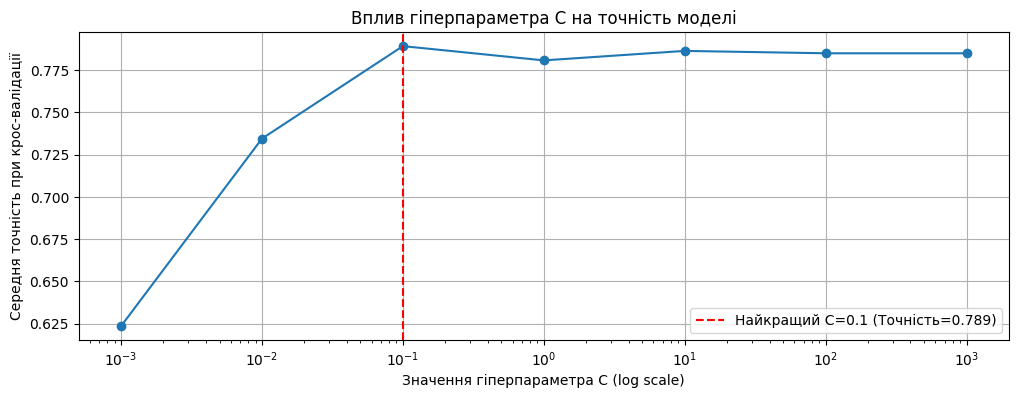

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# --- Завантажуємо дані ---
try:
    df = pd.read_csv('train.csv')
except FileNotFoundError:
    print("Файл train.csv не знайдено. Будь ласка, переконайтеся, що він знаходиться в тій самій папці.")
    exit()


# Обираємо тільки ті стовпці, які вказані в завданні.
features = ['Sex', 'Embarked', 'Pclass', 'Age', 'SibSp', 'Survived']
df = df[features]


# --- Заповненюємо пропуски ---
# У деяких пасажирів не вказано вік. Ми заповнимо ці пропуски середнім віком усіх пасажирів.
mean_age = df['Age'].mean()
df['Age'] = df['Age'].fillna(mean_age)

# Також заповнимо пропуски в 'Embarked', найпопулярнішим портом.
df['Embarked'] = df['Embarked'].fillna(most_frequent_port)


# Використовуємо factorize для ознаки 'Sex'.
# Присвоюємо ('male', 'female') число (0, 1).
df['Sex'] = pd.factorize(df['Sex'])[0]

# Використовуємо One-hot encoding для ознаки 'Embarked'.
# Створює нові окремі стовпці для кожного порту (S, C, Q).
# Наприклад, якщо пасажир сів у порту 'S', у новому стовпці 'Embarked_S' буде 1, а в інших - 0.
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)


# Розділимо наші дані на
X = df.drop('Survived', axis=1)  # "ознаки" (X), за якими ми робимо прогноз
y = df['Survived']  # "ціль" (y), яку ми хочемо передбачити

# Ділимо дані на дві частини : для навчання (80%) і для тестування (20%).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# ---  5-fold Крос-валідація ---
model = LogisticRegression(max_iter=2000)
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print("--- Результати 5-fold Крос-Валідації ---")
print(f"Точність на кожному з 5 фолдів: {np.round(scores, 3)}")
print(f"Середня точність крос-валідації: {scores.mean():.4f}")
print(f"Стандартне відхилення: {scores.std():.4f}\n")
print("-" * 75)


# ---  Підбір гіперпараметрів за допомогою GridSearchCV ---
# Знайдемо значення 'C', при якому модель працює найкраще.
# Задаємо сітку параметрів для перебору.
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

# Створюємо об'єкт GridSearchCV
grid_search = GridSearchCV(LogisticRegression(max_iter=2000), param_grid, cv=5, scoring='accuracy')

# Запускаємо пошук найкращого параметра на тренувальних даних
grid_search.fit(X_train, y_train)
print("--- Результати GridSearchCV ---")
print(f"Найкращий параметр 'C': {grid_search.best_params_}")
print(f"Найкраща точність, знайдена під час пошуку: {grid_search.best_score_:.4f}\n")
print("-" * 75)


# --- Фінальна оцінка та порівняння ---
# Беремо модель з найкращим знайденим параметром 'C'
# Перевіряємо її на тестових даних, які модель ще ніколи не бачила.

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print("--- Порівняння результатів ---")
print(f"Середня точність звичайної крос-валідації: {scores.mean():.4f}")
print(f"Найкраща точність, знайдена GridSearchCV:   {grid_search.best_score_:.4f}")
print(f"Точність найкращої моделі на тестовому наборі: {test_accuracy:.4f}")
print("-" * 75)


# --- Візуалізуємо ---
# Витягуємо результати з grid_search
cv_results = pd.DataFrame(grid_search.cv_results_)
c_values = cv_results['param_C']
mean_scores = cv_results['mean_test_score']

plt.figure(figsize=(12, 4))
plt.plot(c_values, mean_scores, marker='o', linestyle='-')
plt.xscale('log') # Використовуємо логарифмічну шкалу для 'C'
plt.title('Вплив гіперпараметра C на точність моделі')
plt.xlabel('Значення гіперпараметра C (log scale)')
plt.ylabel('Середня точність при крос-валідації')
plt.grid(True)

# Відмічаємо найкращий результат на графіку
best_c = grid_search.best_params_['C']
best_score = grid_search.best_score_
plt.axvline(x=best_c, color='red', linestyle='--', label=f'Найкращий C={best_c} (Точність={best_score:.3f})')
plt.legend()
plt.show()